# Notebook 6

Testing general concepts in ABP

# Section 1

Testing histogram positions agree with predicted exponential law

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from stage_escape.abp_abf.potential import Potential
from stage_escape.abp_abf.transition_detector import TransitionDetector
from stage_escape.abp_abf.abp_metadynamics import ABPMetaDynamics
from stage_escape.abp_abf.distribution_analysis import weighted_histogram_counts, normalize_histogram_counts, extract_coordinate
from stage_escape.visualization import plot_histogram_density
from tqdm import tqdm
from joblib import Parallel, delayed

In [13]:
def run_one_simulation(D, initial_position):
    dt = 0.01
    potential = Potential(1, lambda x: (1 - x[0] ** 2) ** 2, lambda x: -4 * x[0] * (1 - x[0] ** 2))
    td=TransitionDetector(np.array([]), lambda x: -np.inf, 0.0)

    abp = ABPMetaDynamics(num_steps=31, td=td, delta_t=dt, dimension=1, D=D, initial_position=initial_position, b=potential, sigma=0.05)
    abp.simulate(max_iters=100)
    return abp.positions, abp.weights

β^{-1}:   0%|          | 0/8 [00:00<?, ?it/s]/tmp/ipykernel_5275/764655049.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
β^{-1}:  62%|██████▎   | 5/8 [02:31<01:34, 31.35s/it]/home/administrateur/Bureau/STAGE/.venv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
β^{-1}: 100%|██████████| 8/8 [04:09<00:00, 31.16s/it]


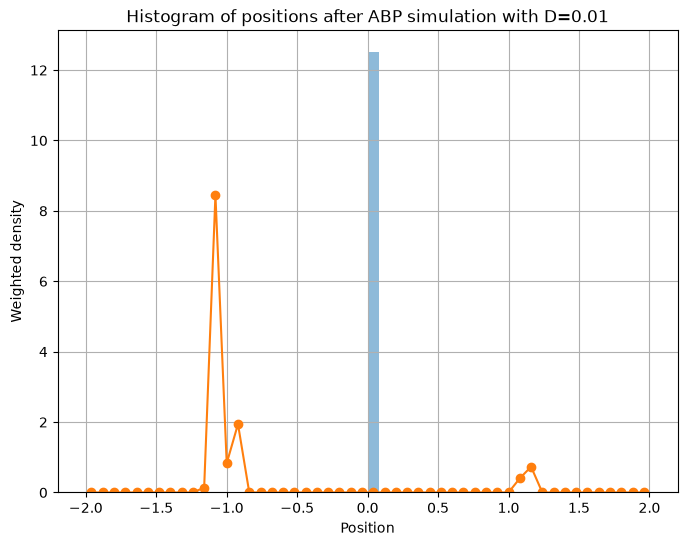

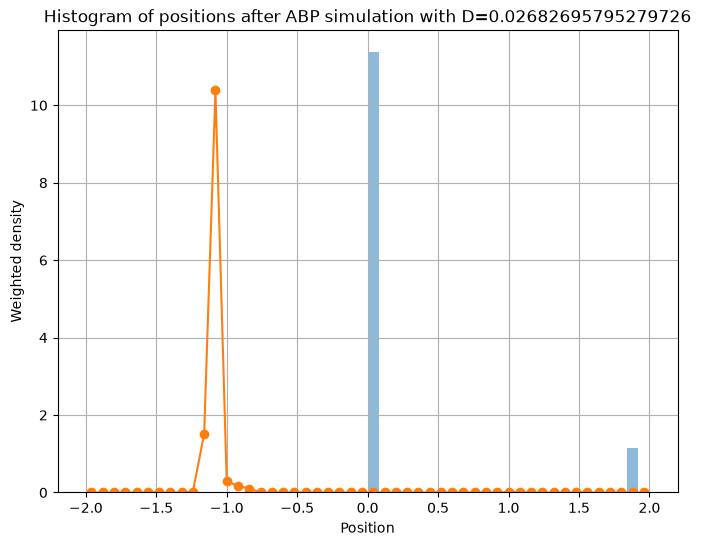

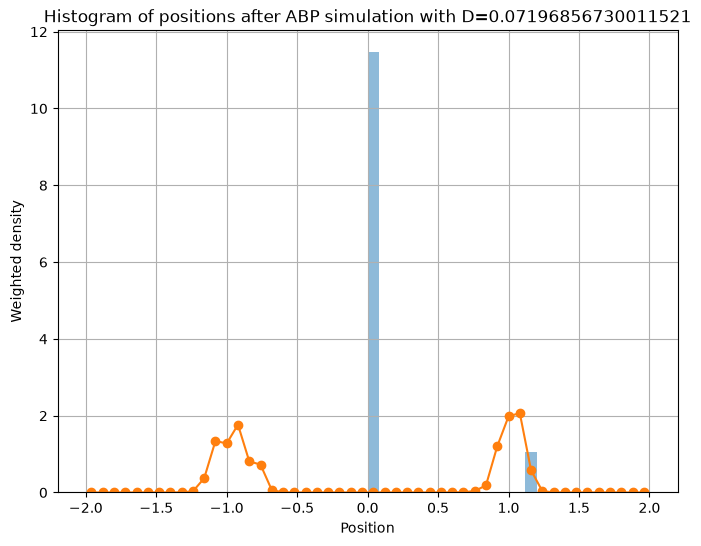

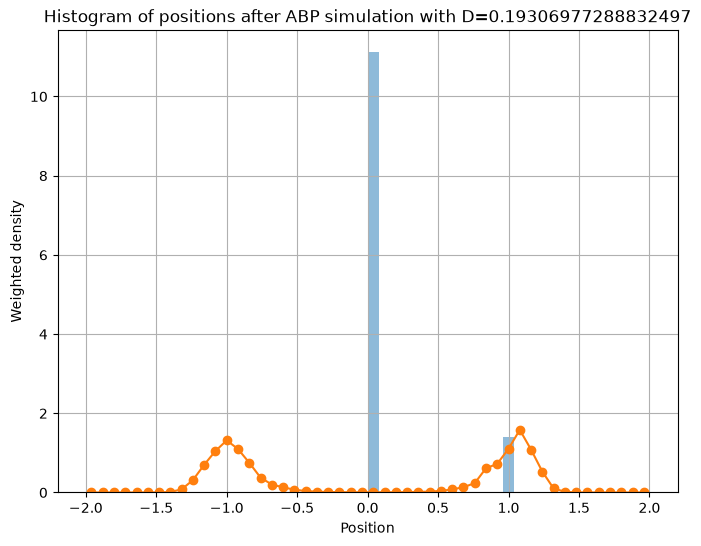

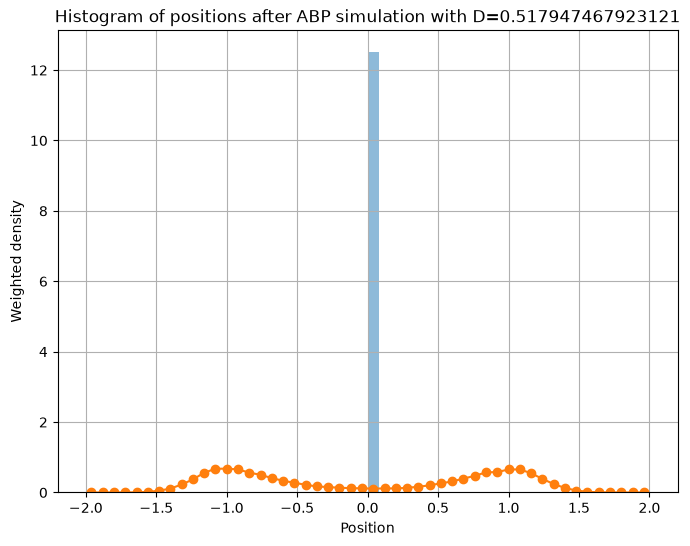

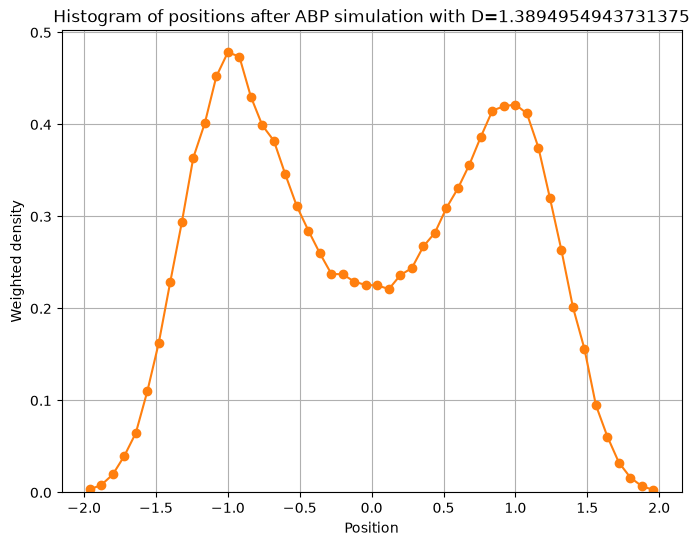

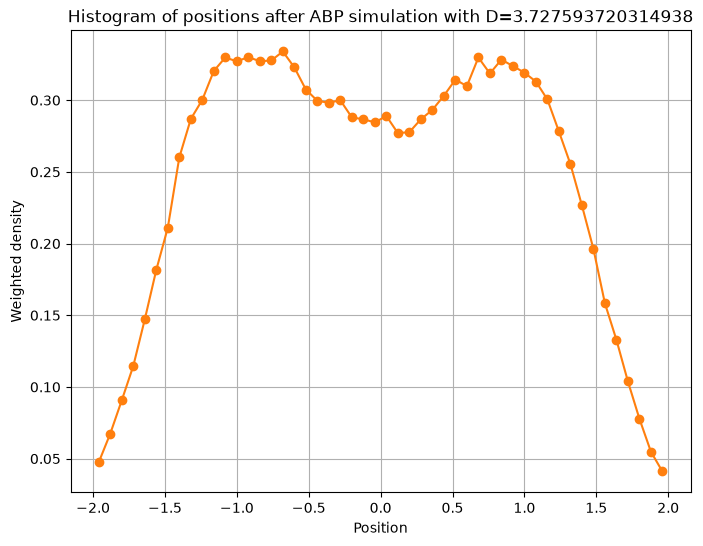

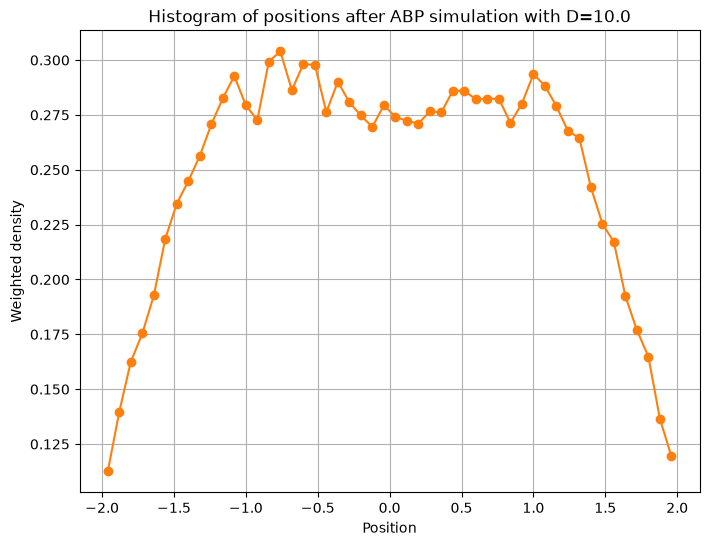

In [15]:
for D in tqdm(np.logspace(-2, 1, 8), desc="β^{-1}"):
    all_counts = None
    bin_edges_ref = None

    results = Parallel(n_jobs=-1)(
        delayed(run_one_simulation)(D, np.array([initial_position]))
        for initial_position in np.arange(-1.5, 1.6, 0.1)
    )    
    
    for positions, weights in results:
        counts, bin_edges = weighted_histogram_counts(
            values=np.array(positions)[:, 0],
            weights=weights,
            bins=50,
            value_range=(-2, 2)
        )

        if all_counts is None:
            all_counts = counts
            bin_edges_ref = bin_edges
        
        else:
            all_counts += counts
    
    bin_centers, density = normalize_histogram_counts(
        counts=all_counts,
        bin_edges=bin_edges_ref,
    )

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    ax.hist(all_counts, bins=bin_edges_ref, density=True, alpha=0.5, label="Weighted histogram")
    plot_histogram_density(
        ax,
        bin_centers=bin_centers,
        density=density,
        title="Histogram of positions after ABP simulation with D={}".format(D),
        xlabel="Position",
        ylabel="Density",
    )

    fig.show()

# Section 2

Working with a 2d potential harder than the previous ones

In [ ]:
def entropic_switch(x, y):
    tmp1 = x**2
    tmp2 = (y - 1 / 3)**2
    return 3 * np.exp(-tmp1) * (np.exp(-tmp2) - np.abs(np.exp(-(y - 5 / 3)**2))) - 5 * np.exp(-y**2) * (np.exp(-(x - 1)**2) + np.exp(-(x + 1)**2)) + 0.2 * tmp1**2 + 0.2 * tmp2**2

def grad_entropic_switch(x, y):

    tmp1 = np.exp(4*x)
    tmp2 = np.exp(-x**2 - 2*x - y**2 - 1)
    tmp3 = np.exp(-x**2)
    tmp4 = np.exp(-(y-1/3)**2)
    tmp5 = np.exp(-(y-5/3)**2)

    dx = 0.8*x**3 + 10*(tmp1*(x - 1) + x + 1)*tmp2 - 6*tmp3*x*(tmp4 - tmp5)

    dy = 10*(tmp1 + 1)*y*tmp2 + 3*tmp3*(2*tmp5*(y - 5/3) - 2*tmp4*(y - 1/3)) + 0.8*(y - 1/3)**3

    return np.array([dx, dy])

In [ ]:
def run_one_simulation(D, initial_position):
    dt = 0.01
    potential = Potential(2, lambda x: entropic_switch(x[0], x[1]), lambda x: grad_entropic_switch(x[0], x[1]))
    td=TransitionDetector(np.array([]), lambda x: -np.inf, 0.0)

    abp = ABPMetaDynamics(num_steps=31, td=td, delta_t=dt, dimension=2, D=D, initial_position=initial_position, b=potential, sigma=0.05)
    abp.simulate(max_iters=1e4)
    return abp.positions, abp.weights

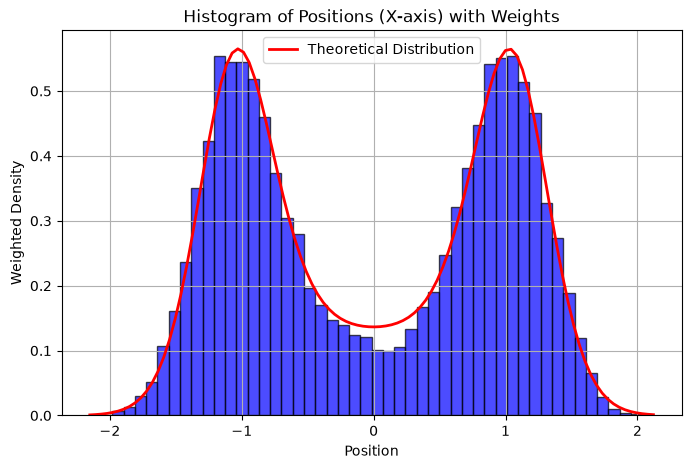

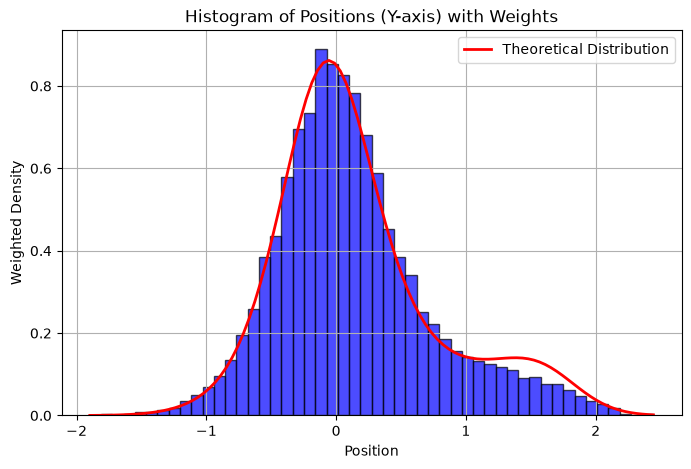

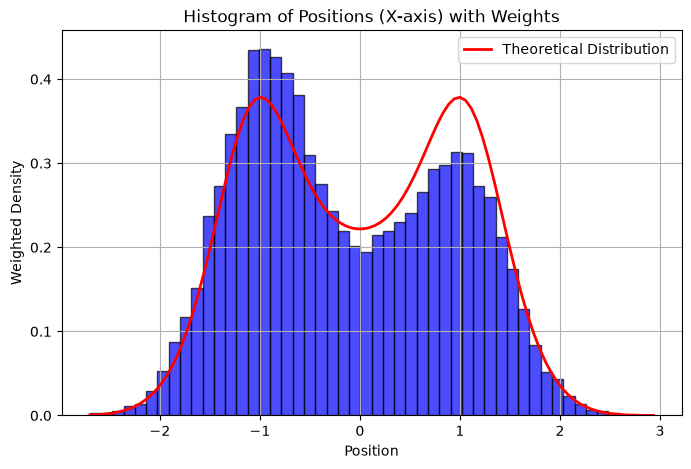

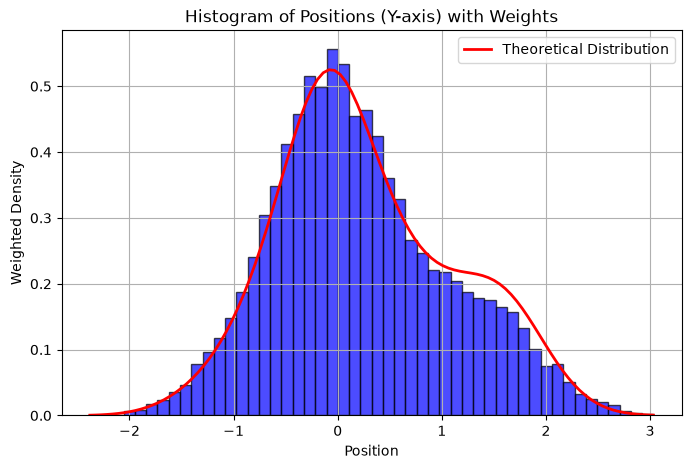

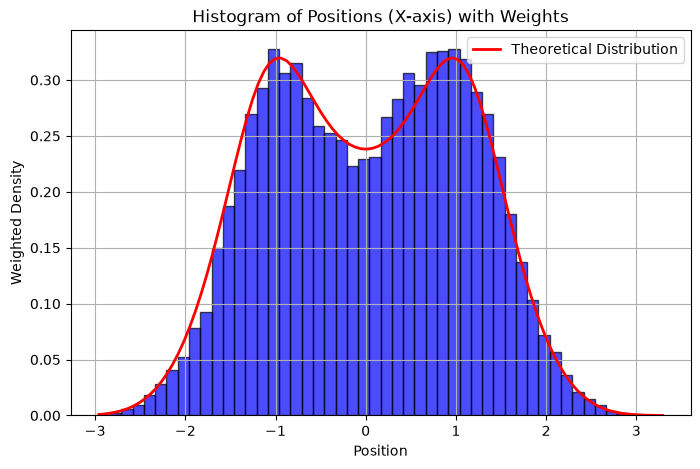

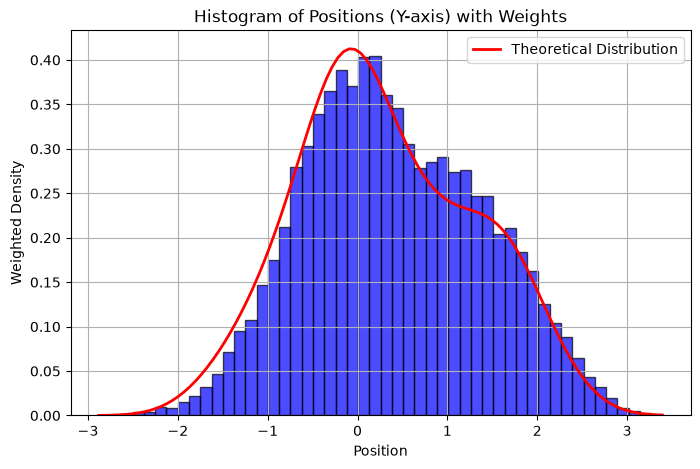

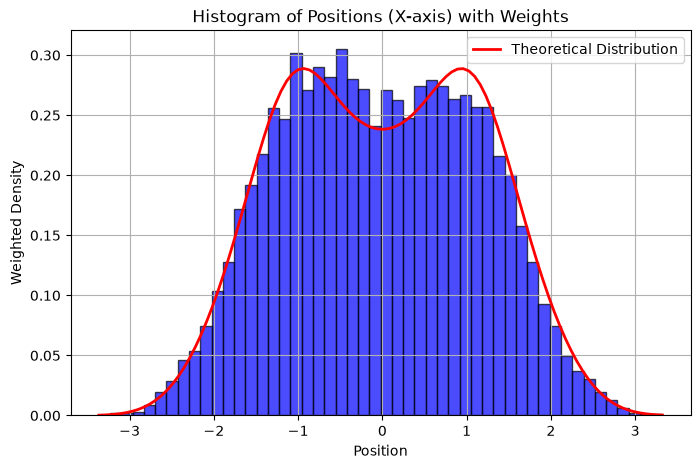

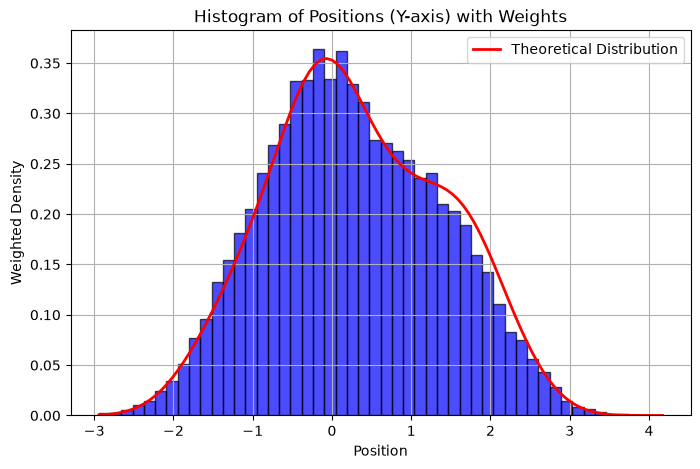

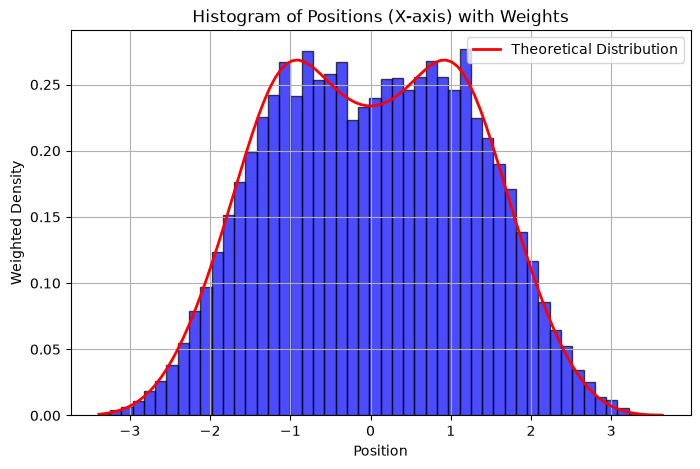

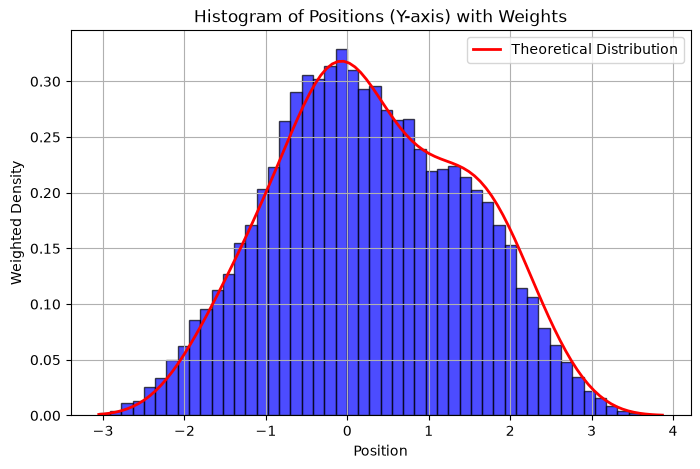

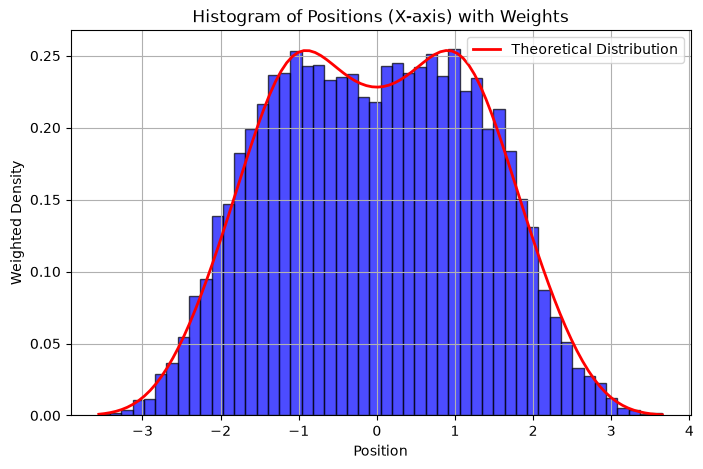

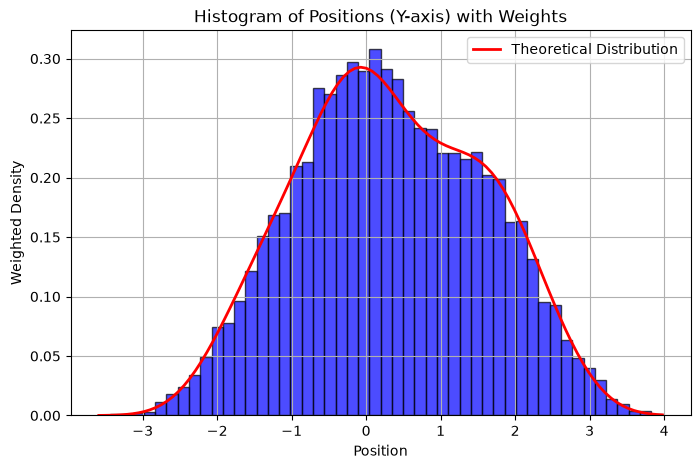

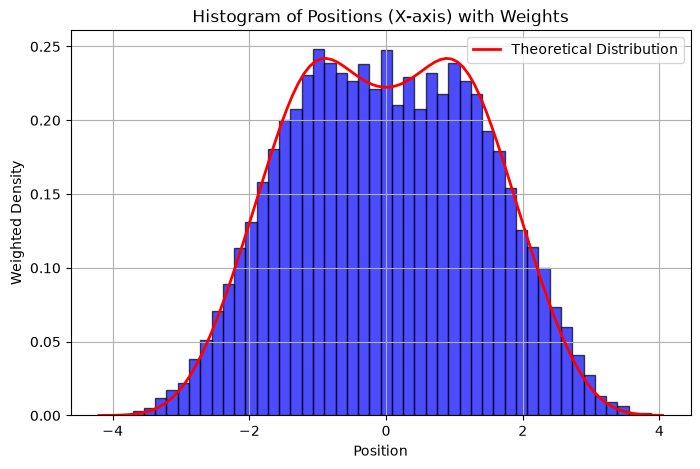

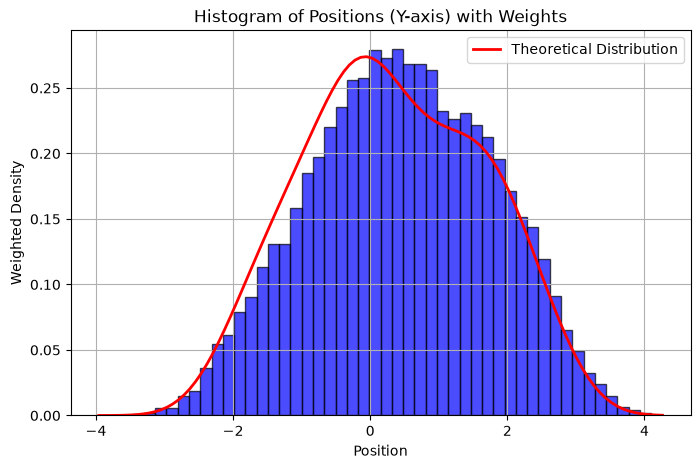

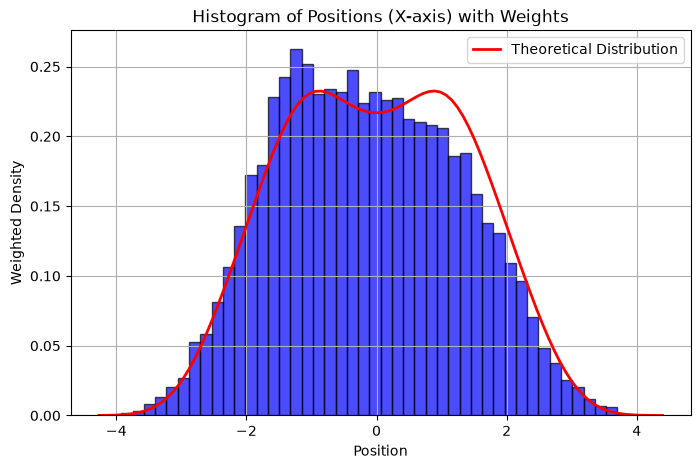

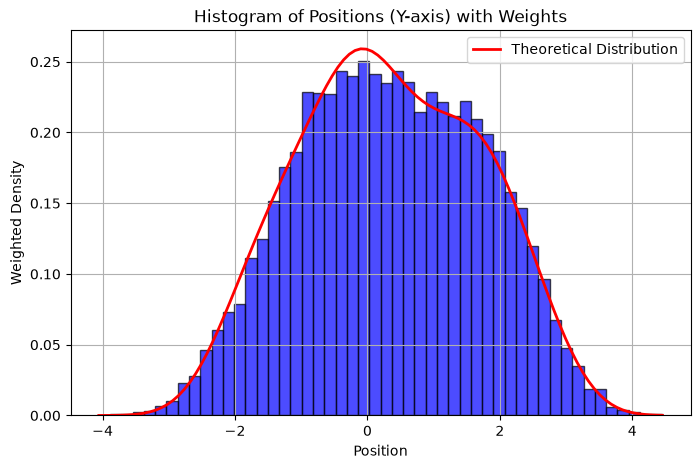

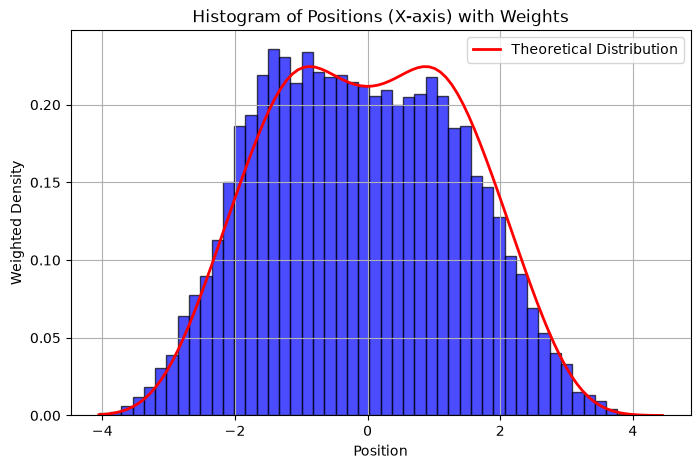

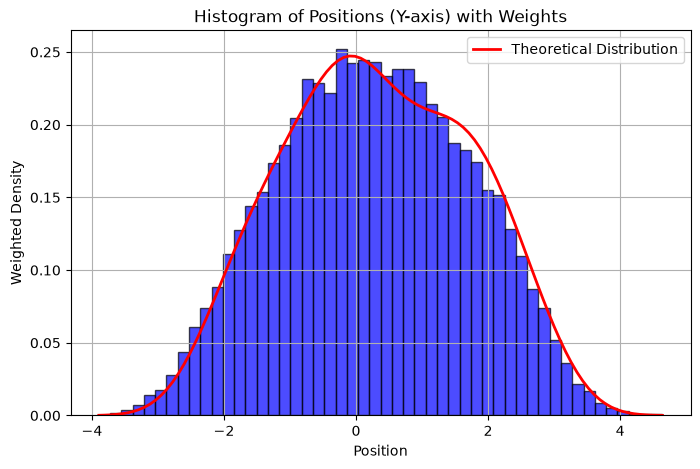

In [ ]:
for D in tqdm(np.logspace(-4, 1, 8), desc="β^{-1}"):
    all_counts_x = None
    all_counts_y = None
    bin_edges_ref = None

    results = Parallel(n_jobs=-1)(
        delayed(run_one_simulation)(D, np.array([initx, inity]))
        for initx, inity in zip(np.random.shuffle(np.arange(-1.5, 1.6, 0.1)), np.random.shuffle(np.arange(-1.5, 1.6, 0.1)))
    )    

    for positions, weights in results:
        positions_x = extract_coordinate(positions, axis=0)
        positions_y = extract_coordinate(positions, axis=1)
        
        counts_x, bin_edges_x = weighted_histogram_counts(
            values=positions_x,
            weights=weights,
            bins=50,
            value_range=(-2, 2)
        )
        counts_y, bin_edges_y = weighted_histogram_counts(
            values=positions_y,
            weights=weights,
            bins=50,
            value_range=(-2, 2)
        )

        if all_counts_x is None:
            all_counts_x = counts_x
            bin_edges_ref = bin_edges_x
        else:
            all_counts_x += counts_x

        if all_counts_y is None:
            all_counts_y = counts_y
            bin_edges_ref = bin_edges_y
        else:
            all_counts_y += counts_y

    bin_centers_x, density_x = normalize_histogram_counts(
        counts=all_counts_x,
        bin_edges=bin_edges_ref,
    )

    bin_centers_y, density_y = normalize_histogram_counts(
        counts=all_counts_y,
        bin_edges=bin_edges_ref,
    )

    plot_histogram_density(
        bin_centers=bin_centers_x,
        density=density_x,
        title="Histogram of positions after ABP simulation with D={}".format(D),
        xlabel="Position",
        ylabel="Density",
    )
    
    plot_histogram_density(
        bin_centers=bin_centers_y,
        density=density_y,
        title="Histogram of positions after ABP simulation with D={}".format(D),
        xlabel="Position",
        ylabel="Density",
    )